# DKD + Dual Learnable Temperatures (CTKD-style) — CIFAR-100

---

### Method Summary

This notebook combines **Decoupled Knowledge Distillation** (Zhao et al., CVPR 2022) with
**dual learnable temperatures** inspired by CTKD (Li et al., ECCV 2022), using the
**same training methodology as the retrained MobileNetV2 baselines** (SGD + Nesterov,
CosineAnnealingLR, 125 epochs, batch 128, no pretrained weights, label-smoothed CE).

Two independently learnable temperatures — one per DKD component — are each driven by a
Gradient Reversal Layer:

$$\mathcal{L}_{TCKD} = \text{BCE}\bigl(\sigma(z^T / \tau_{TCKD}),\; \sigma(z^S / \tau_{TCKD})\bigr)$$

$$\mathcal{L}_{NCKD} = \text{KL}\bigl(\hat{p}^T(\tau_{NCKD}) \| \hat{p}^S(\tau_{NCKD})\bigr)$$

$$\mathcal{L} = \mathcal{L}_{CE}^{\text{smooth}} + \alpha \cdot \mathcal{L}_{TCKD} + \beta \cdot \mathcal{L}_{NCKD}$$

The GRL creates an adversarial curriculum: both temperatures are pushed to maximise the loss
while the student minimises it. Crucially, $\tau_{TCKD}$ and $\tau_{NCKD}$ evolve independently,
allowing the two KD components to find their own optimal difficulty trajectory.

---
**Teacher:** ResNet-18 loaded from `checkpoints/b1_resnet18_teacher_cifar100.pth`  
**Student:** MobileNetV2 trained from scratch (no pretrained weights)  
**Training regime:** SGD + Nesterov, CosineAnnealingLR T_max=125 eta_min=1e-4, lr=0.05, wd=1e-4  
**Checkpoint:** `b6_mobilenetv2_dkd_dual_temp_cifar100_cosine.pth`


## 1. Environment Setup

In [29]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader

import torchvision
import torchvision.transforms as transforms
import torchvision.datasets as datasets
import torchvision.models as models

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from tqdm import tqdm
from pathlib import Path
import json
import warnings
warnings.filterwarnings('ignore')

SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark     = False

DEVICE  = 'cuda' if torch.cuda.is_available() else 'cpu'
USE_AMP = torch.cuda.is_available()

print(f'Device      : {DEVICE}')
if DEVICE == 'cuda':
    print(f'GPU         : {torch.cuda.get_device_name(0)}')
print(f'PyTorch     : {torch.__version__}')
print(f'Mixed prec. : {USE_AMP}')


Device      : cuda
GPU         : NVIDIA GeForce RTX 3050 6GB Laptop GPU
PyTorch     : 2.5.1
Mixed prec. : True


## 2. Configuration

In [30]:
DATA_DIR = Path('./data')
CKPT_DIR = Path('./checkpoints')
CKPT_DIR.mkdir(parents=True, exist_ok=True)

TEACHER_CKPT = CKPT_DIR / 'best_teacher.pth'

NUM_CLASSES = 100
CIFAR_MEAN  = (0.5071, 0.4867, 0.4408)
CIFAR_STD   = (0.2675, 0.2565, 0.2761)

# -- Training schedule (matches retrained baseline notebook) ------------------
EPOCHS     = 125
BATCH_SIZE = 128

LR           = 0.05    # CHANGED: was 0.1
MOMENTUM     = 0.9
WEIGHT_DECAY = 1e-4    # CHANGED: was 5e-4
# Scheduler: CosineAnnealingLR T_max=125 eta_min=1e-4  (was MultiStepLR)
# LR_MILESTONES / LR_GAMMA removed — no longer used

# -- DKD loss weights ---------------------------------------------------------
ALPHA = 1.0   # weight on TCKD loss  (unchanged)
BETA  = 8.0   # weight on NCKD loss  (CHANGED: was 1.0, then 2.0)

# -- Temperature constraints --------------------------------------------------
TAU_MIN = 2.0    # sigmoid lower bound
TAU_MAX = 10.0   # sigmoid upper bound

# -- Temperature learning rate (separate group) --------------------------------
LR_TEMP = 1e-3

# -- GRL lambda schedule ------------------------------------------------------
GRL_LAMBDA_MAX = 1.0

# CE loss: label_smoothing=0.1 -- see Loss section

print('Configuration loaded.')
print(f'  Epochs         : {EPOCHS}')
print(f'  Batch size     : {BATCH_SIZE}')
print(f'  LR             : {LR}  (was 0.1)')
print(f'  Weight decay   : {WEIGHT_DECAY}  (was 5e-4)')
print(f'  Scheduler      : CosineAnnealingLR T_max={EPOCHS} eta_min=1e-4  (was MultiStepLR)')
print(f'  alpha / beta   : {ALPHA} / {BETA}  (beta was 1.0)')
print(f'  tau range      : [{TAU_MIN}, {TAU_MAX}]')
print(f'  LR_TEMP        : {LR_TEMP}')
print(f'  GRL lambda max : {GRL_LAMBDA_MAX}')
print(f'  CE loss        : label_smoothing=0.1  (was 0.0)')


Configuration loaded.
  Epochs         : 125
  Batch size     : 128
  LR             : 0.05  (was 0.1)
  Weight decay   : 0.0001  (was 5e-4)
  Scheduler      : CosineAnnealingLR T_max=125 eta_min=1e-4  (was MultiStepLR)
  alpha / beta   : 1.0 / 8.0  (beta was 1.0)
  tau range      : [2.0, 10.0]
  LR_TEMP        : 0.001
  GRL lambda max : 1.0
  CE loss        : label_smoothing=0.1  (was 0.0)


## 3. Data Pipeline — CIFAR-100

In [31]:
train_transform = transforms.Compose([
    transforms.RandomCrop(32, padding=4),
    transforms.RandomHorizontalFlip(),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    transforms.ToTensor(),
    transforms.Normalize(CIFAR_MEAN, CIFAR_STD),
    transforms.RandomErasing(p=0.25),   # matches retrained baseline notebook
])

test_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(CIFAR_MEAN, CIFAR_STD),
])

train_ds = datasets.CIFAR100(root=DATA_DIR, train=True,  download=True, transform=train_transform)
test_ds  = datasets.CIFAR100(root=DATA_DIR, train=False, download=True, transform=test_transform)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,  num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_ds,  batch_size=256,        shuffle=False, num_workers=2, pin_memory=True)

print(f'Train : {len(train_ds):,} samples  ({len(train_loader)} batches)')
print(f'Test  : {len(test_ds):,} samples  ({len(test_loader)} batches)')
print(f'Image : {train_ds[0][0].shape}  (C x H x W)')


Files already downloaded and verified
Files already downloaded and verified
Train : 50,000 samples  (391 batches)
Test  : 10,000 samples  (40 batches)
Image : torch.Size([3, 32, 32])  (C x H x W)


## 4. Model Definitions

### 4.1 Teacher — ResNet-18

Teacher-loading logic identical to the original DKD+CTKD notebook: auto-detects conv1 kernel size,
handles both CIFAR-adapted (3×3) and standard (7×7) checkpoints, and strips DataParallel prefixes.


In [32]:
def build_resnet18_cifar(num_classes):
    m = models.resnet18(weights=None)
    m.conv1   = nn.Conv2d(3, 64, kernel_size=3, stride=1, padding=1, bias=False)
    m.maxpool = nn.Identity()
    m.fc      = nn.Linear(512, num_classes)
    return m


def build_resnet18_standard(num_classes):
    m = models.resnet18(weights=None)
    m.fc = nn.Linear(512, num_classes)
    return m


def load_teacher(ckpt_path, num_classes, device):
    """
    Robust teacher loader — identical to the original DKD+CTKD notebook.
    Handles {'state_dict': ..., ...} and raw state_dict formats.
    Strips 'module.' prefix from DataParallel saves.
    Auto-detects conv1 architecture from checkpoint weight tensor shape.
    """
    raw   = torch.load(ckpt_path, map_location=device)
    state = raw.get('state_dict', raw) if isinstance(raw, dict) else raw
    state = {k.replace('module.', ''): v for k, v in state.items()}

    conv1_kernel = state['conv1.weight'].shape[2]

    if conv1_kernel == 3:
        print(f'  Detected conv1 kernel=3x3 -> building CIFAR-adapted ResNet-18')
        model = build_resnet18_cifar(num_classes).to(device)
    else:
        print(f'  Detected conv1 kernel=7x7 -> building standard ResNet-18')
        model = build_resnet18_standard(num_classes).to(device)

    missing, unexpected = model.load_state_dict(state, strict=False)
    if missing:
        print(f'  [WARN] Missing keys   : {missing}')
    if unexpected:
        print(f'  [WARN] Unexpected keys: {unexpected}')

    model.eval()
    for p in model.parameters():
        p.requires_grad = False

    reported = raw.get('top1', raw.get('val_top1', 'N/A')) if isinstance(raw, dict) else 'N/A'
    print(f'Teacher loaded from  : {ckpt_path}')
    print(f'  conv1 kernel       : {conv1_kernel}x{conv1_kernel}')
    print(f'  Checkpoint top-1   : {reported}')
    return model


teacher = load_teacher(TEACHER_CKPT, NUM_CLASSES, DEVICE)
print(f'  Trainable params   : {sum(p.numel() for p in teacher.parameters() if p.requires_grad)}')
print('  Teacher is frozen -- will never update during training.')


  Detected conv1 kernel=3x3 -> building CIFAR-adapted ResNet-18
Teacher loaded from  : checkpoints/best_teacher.pth
  conv1 kernel       : 3x3
  Checkpoint top-1   : N/A
  Trainable params   : 0
  Teacher is frozen -- will never update during training.


### 4.2 Student — MobileNetV2 (from scratch)

In [33]:
def build_mobilenetv2_cifar(num_classes):
    """MobileNetV2 for 32x32 CIFAR, trained from scratch."""
    m = models.mobilenet_v2(weights=None)
    m.features[0][0] = nn.Conv2d(3, 32, kernel_size=3, stride=1, padding=1, bias=False)
    m.classifier = nn.Sequential(
        nn.Dropout(0.2),
        nn.Linear(m.last_channel, num_classes),
    )
    return m


student = build_mobilenetv2_cifar(NUM_CLASSES).to(DEVICE)

total_p     = sum(p.numel() for p in student.parameters()) / 1e6
trainable_p = sum(p.numel() for p in student.parameters() if p.requires_grad) / 1e6
print(f'Student : MobileNetV2  |  {total_p:.2f}M total  |  {trainable_p:.2f}M trainable')
print('Weights : randomly initialised (no pretrained backbone) -- matches baseline methodology.')


Student : MobileNetV2  |  2.35M total  |  2.35M trainable
Weights : randomly initialised (no pretrained backbone) -- matches baseline methodology.


## 5. Gradient Reversal Layer (GRL)

Identical to the original DKD+CTKD notebook.
Forward is identity; backward multiplies gradients by $-\lambda$.

$\lambda$ is annealed from 0 to `GRL_LAMBDA_MAX` via the sigmoid schedule from CTKD:

$$\lambda(p) = \frac{2 \cdot \lambda_{max}}{1 + e^{-10p}} - \lambda_{max}, \quad p = \frac{\text{epoch}}{\text{total\_epochs}}$$


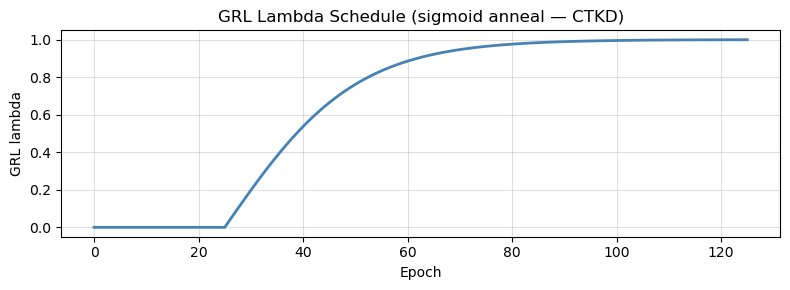

lambda at epoch   0 : 0.0000
lambda at epoch   31 : 0.2355
lambda at epoch   62 : 0.9015
lambda at epoch 125 : 0.9993


In [34]:
class GradientReversalFunction(torch.autograd.Function):
    @staticmethod
    def forward(ctx, x, grl_lambda):
        ctx.save_for_backward(torch.tensor(grl_lambda))
        return x.clone()

    @staticmethod
    def backward(ctx, grad_output):
        grl_lambda, = ctx.saved_tensors
        return -grl_lambda.item() * grad_output, None


def grad_reverse(x, grl_lambda):
    return GradientReversalFunction.apply(x, grl_lambda)


def compute_grl_lambda(epoch, total_epochs, lambda_max=GRL_LAMBDA_MAX):
    """Sigmoid-annealed GRL schedule from CTKD (Li et al., ECCV 2022)."""
    p = max((epoch - 25) / total_epochs, 0.0)  # Start increasing lambda after 20% of training (25/125 epochs)
    return (2.0 * lambda_max) / (1.0 + np.exp(-10.0 * p)) - lambda_max


ep_range = np.arange(0, EPOCHS + 1)
lambdas  = [compute_grl_lambda(e, EPOCHS) for e in ep_range]

fig, ax = plt.subplots(figsize=(8, 3))
ax.plot(ep_range, lambdas, color='steelblue', linewidth=2)
ax.set_xlabel('Epoch'); ax.set_ylabel('GRL lambda')
ax.set_title('GRL Lambda Schedule (sigmoid anneal — CTKD)')
ax.grid(True, alpha=0.4)
plt.tight_layout(); plt.show()

print(f'lambda at epoch   0 : {compute_grl_lambda(0,          EPOCHS):.4f}')
print(f'lambda at epoch  {EPOCHS//4:3d} : {compute_grl_lambda(EPOCHS//4,  EPOCHS):.4f}')
print(f'lambda at epoch  {EPOCHS//2:3d} : {compute_grl_lambda(EPOCHS//2,  EPOCHS):.4f}')
print(f'lambda at epoch {EPOCHS:3d} : {compute_grl_lambda(EPOCHS,     EPOCHS):.4f}')


## 6. Dual Learnable Temperature Module

Two independently learnable temperature scalars — one for TCKD, one for NCKD.
Each is constrained to $[\tau_{min}, \tau_{max}]$ via sigmoid scaling:

$$\tau = \tau_{min} + (\tau_{max} - \tau_{min}) \cdot \sigma(\phi)$$

Both initialised to $\tau = 4.0$ (classical KD starting point).
The GRL is applied to each $\phi$ independently, so they can diverge to different
optimal values as training progresses.


In [35]:
class DualTemperatureModule(nn.Module):
    """
    Two independently learnable temperatures for TCKD and NCKD.

    Identical architecture to the original DKD+CTKD notebook.
    Both temperatures initialised at tau=4.0 and constrained to [tau_min, tau_max].
    GRL is applied during forward so temperatures maximise the loss adversarially.
    """

    def __init__(self, tau_min=TAU_MIN, tau_max=TAU_MAX):
        super().__init__()
        self.tau_min = tau_min
        self.tau_max = tau_max

        # Initialise at tau = 4.0
        init_ratio = (4.0 - tau_min) / (tau_max - tau_min)
        init_phi   = np.log(init_ratio / (1.0 - init_ratio))  # inverse sigmoid

        self.phi_tckd = nn.Parameter(torch.tensor(init_phi, dtype=torch.float32))
        self.phi_nckd = nn.Parameter(torch.tensor(init_phi, dtype=torch.float32))

    def _constrain(self, phi):
        return self.tau_min + (self.tau_max - self.tau_min) * torch.sigmoid(phi)

    def tau_tckd(self):
        """Current TCKD temperature (no GRL, for logging)."""
        return self._constrain(self.phi_tckd)

    def tau_nckd(self):
        """Current NCKD temperature (no GRL, for logging)."""
        return self._constrain(self.phi_nckd)

    def forward(self, grl_lambda):
        """Returns (tau_tckd, tau_nckd) with GRL applied for adversarial update."""
        phi_t = grad_reverse(self.phi_tckd, grl_lambda)
        phi_n = grad_reverse(self.phi_nckd, grl_lambda)
        return (
            self.tau_min + (self.tau_max - self.tau_min) * torch.sigmoid(phi_t),
            self.tau_min + (self.tau_max - self.tau_min) * torch.sigmoid(phi_n),
        )


temp_module = DualTemperatureModule(TAU_MIN, TAU_MAX).to(DEVICE)

print('DualTemperatureModule initialised.')
print(f'  tau_tckd at init : {temp_module.tau_tckd().item():.4f}  (target: 4.0)')
print(f'  tau_nckd at init : {temp_module.tau_nckd().item():.4f}  (target: 4.0)')
print(f'  tau range        : [{TAU_MIN}, {TAU_MAX}]')
print(f'  Trainable params : {sum(p.numel() for p in temp_module.parameters())}')


DualTemperatureModule initialised.
  tau_tckd at init : 4.0000  (target: 4.0)
  tau_nckd at init : 4.0000  (target: 4.0)
  tau range        : [2.0, 10.0]
  Trainable params : 2


## 7. DKD Loss with Dual Learnable Temperatures

Identical loss formulation to the original DKD+CTKD notebook.
TCKD uses binary-distribution BCE at $\tau_{TCKD}$; NCKD uses KL over non-target classes at $\tau_{NCKD}$.


In [36]:
class DKDDualTempLoss(nn.Module):
    """
    DKD loss with independently learnable temperatures for TCKD and NCKD.

    CE is computed via criterion_ce (label_smoothing=0.1) passed in from the caller,
    matching the retrained baseline where label-smoothed CE is used throughout.

    Args:
        alpha : weight on TCKD loss  (default 1.0)
        beta  : weight on NCKD loss  (default 2.0)

    Forward:
        s_logits    : (B, C) student logits
        t_logits    : (B, C) teacher logits  (no_grad expected from caller)
        labels      : (B,)   integer ground-truth labels
        tau_tckd    : scalar tensor -- temperature for TCKD (with GRL applied)
        tau_nckd    : scalar tensor -- temperature for NCKD (with GRL applied)
        criterion_ce: nn.CrossEntropyLoss(label_smoothing=0.1) -- passed in

    Returns:
        total_loss, tckd_loss (detached), nckd_loss (detached), ce_loss (detached)
    """

    def __init__(self, alpha=ALPHA, beta=BETA):
        super().__init__()
        self.alpha = alpha
        self.beta  = beta

    @staticmethod
    def _split_logits(logits, labels):
        B, C    = logits.shape
        gt_mask = F.one_hot(labels, C).bool()
        tgt     = logits[gt_mask].unsqueeze(1)      # (B, 1)
        rest    = logits[~gt_mask].view(B, C - 1)   # (B, C-1)
        return tgt, rest

    def forward(self, s_logits, t_logits, labels, tau_tckd, tau_nckd, criterion_ce):
        # CHANGED: label-smoothed CE (was F.cross_entropy with no smoothing)
        ce_loss = criterion_ce(s_logits, labels)

        s_tgt, s_rest = self._split_logits(s_logits, labels)
        t_tgt, t_rest = self._split_logits(t_logits, labels)

        # -- TCKD: binary distribution BCE ------------------------------------
        s_bin = torch.cat([s_tgt, s_rest.logsumexp(dim=1, keepdim=True)], dim=1)
        t_bin = torch.cat([t_tgt, t_rest.logsumexp(dim=1, keepdim=True)], dim=1)

        s_bin_prob = torch.softmax(s_bin / tau_tckd, dim=1)
        t_bin_prob = torch.softmax(t_bin / tau_tckd, dim=1)
        tckd_loss  = -(t_bin_prob * torch.log(s_bin_prob + 1e-8)).sum(dim=1).mean()

        # -- NCKD: KL over non-target classes ---------------------------------
        s_nckd    = F.log_softmax(s_rest / tau_nckd, dim=1)
        t_nckd    = F.softmax(t_rest    / tau_nckd, dim=1)
        nckd_loss = F.kl_div(s_nckd, t_nckd, reduction='batchmean')

        # total = CE + alpha*TCKD + beta*NCKD  (CE is label-smoothed)
        total = ce_loss + self.alpha * tckd_loss + self.beta * nckd_loss

        return total, tckd_loss.detach(), nckd_loss.detach(), ce_loss.detach()


# Label-smoothed CE -- used inside DKDDualTempLoss and logged separately
criterion_ce = nn.CrossEntropyLoss(label_smoothing=0.1)
criterion     = DKDDualTempLoss(alpha=ALPHA, beta=BETA)

print('DKDDualTempLoss instantiated.')
print(f'  alpha (TCKD weight) : {criterion.alpha}')
print(f'  beta  (NCKD weight) : {criterion.beta}')
print(f'  CE    (label smooth): label_smoothing=0.1')


DKDDualTempLoss instantiated.
  alpha (TCKD weight) : 1.0
  beta  (NCKD weight) : 8.0
  CE    (label smooth): label_smoothing=0.1


## 8. Optimiser and Scheduler

SGD + Nesterov, CosineAnnealingLR — identical to the retrained baseline notebook.
Temperature parameters in a separate param group with their own LR so they are
unaffected by the student's cosine decay.


In [37]:
student_params = list(student.parameters())
temp_params    = list(temp_module.parameters())

optimizer = torch.optim.SGD([
    {'params': student_params, 'lr': LR},
    {'params': temp_params,    'lr': LR_TEMP},
], momentum=MOMENTUM, weight_decay=WEIGHT_DECAY, nesterov=True)

scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer,
    T_max=EPOCHS,
    eta_min=1e-4
)

print('Optimiser and scheduler configured.')
print(f'  Optimiser    : SGD (Nesterov)  student lr={LR}  temp lr={LR_TEMP}')
print(f'  Scheduler    : CosineAnnealingLR  T_max={EPOCHS}  eta_min=1e-4')
print(f'  WD           : {WEIGHT_DECAY}')
print(f'  Student params  : {sum(p.numel() for p in student_params)/1e6:.2f}M')
print(f'  Temp params     : {sum(p.numel() for p in temp_params)}')


Optimiser and scheduler configured.
  Optimiser    : SGD (Nesterov)  student lr=0.05  temp lr=0.001
  Scheduler    : CosineAnnealingLR  T_max=125  eta_min=1e-4
  WD           : 0.0001
  Student params  : 2.35M
  Temp params     : 2


## 9. Evaluation Utility

In [38]:
@torch.no_grad()
def evaluate(model, loader, device):
    """Top-1 and Top-5 accuracy."""
    model.eval()
    top1_c = top5_c = total = 0
    for imgs, labels in tqdm(loader, desc='Eval', leave=False, dynamic_ncols=True):
        imgs, labels = imgs.to(device), labels.to(device)
        logits = model(imgs)
        top1_c += (logits.argmax(1) == labels).sum().item()
        top5_c += (logits.topk(5, dim=1).indices == labels.unsqueeze(1)).any(1).sum().item()
        total  += labels.size(0)
    return 100.0 * top1_c / total, 100.0 * top5_c / total

print('evaluate() ready -- returns (top1 %, top5 %).')


evaluate() ready -- returns (top1 %, top5 %).


## 10. Training Loop

In [39]:
def train_one_epoch(student, teacher, temp_module, criterion, criterion_ce,
                    optimizer, loader, grl_lambda, device, epoch, total_epochs):
    """One epoch of DKD + dual-temp adversarial training. Returns dict of averaged metrics."""
    student.train()
    teacher.eval()          # teacher always in eval mode
    for p in teacher.parameters():
        p.requires_grad_(False)   # ensure teacher params never accumulate grads
    temp_module.train()

    sums = dict(total=0., tckd=0., nckd=0., ce=0., correct=0, n=0)
    pbar = tqdm(loader, desc=f'Ep {epoch:3d}/{total_epochs}', leave=False, dynamic_ncols=True)

    for imgs, labels in pbar:
        imgs, labels = imgs.to(device), labels.to(device)
        B = imgs.size(0)

        with torch.no_grad():
            t_logits = teacher(imgs)

        optimizer.zero_grad()
        s_logits = student(imgs)

        # GRL disabled for first 5 epochs for stable warmup
        effective_lambda = grl_lambda if epoch > 5 else 0.0
        tau_t, tau_n = temp_module(effective_lambda)

        total_loss, tckd_l, nckd_l, ce_l = criterion(
            s_logits, t_logits, labels, tau_t, tau_n, criterion_ce
        )
        total_loss.backward()
        optimizer.step()

        sums['total']   += total_loss.item() * B
        sums['tckd']    += tckd_l.item()     * B
        sums['nckd']    += nckd_l.item()     * B
        sums['ce']      += ce_l.item()        * B
        sums['correct'] += (s_logits.argmax(1) == labels).sum().item()
        sums['n']       += B

        pbar.set_postfix(
            loss=f'{total_loss.item():.3f}',
            tau_t=f'{tau_t.item():.2f}',
            tau_n=f'{tau_n.item():.2f}',
        )

    n = sums['n']
    return {
        'total_loss' : sums['total'] / n,
        'tckd_loss'  : sums['tckd'] / n,
        'nckd_loss'  : sums['nckd'] / n,
        'ce_loss'    : sums['ce']   / n,
        'train_acc'  : 100.0 * sums['correct'] / n,
        'tau_tckd'   : temp_module.tau_tckd().item(),
        'tau_nckd'   : temp_module.tau_nckd().item(),
        'grl_lambda' : grl_lambda,
    }

print('train_one_epoch() defined.')


train_one_epoch() defined.


## 11. Training Run

In [40]:
history = {
    'epoch': [], 'total_loss': [], 'tckd_loss': [], 'nckd_loss': [], 'ce_loss': [],
    'train_acc': [], 'test_top1': [], 'test_top5': [],
    'tau_tckd': [], 'tau_nckd': [], 'grl_lambda': [],
}

best_top1  = 0.0
best_epoch = 0

print('Starting DKD + Dual Learnable Temperature training...')
print(f'  Epochs       : {EPOCHS}')
print(f'  alpha / beta : {ALPHA} / {BETA}')
print(f'  tau range    : [{TAU_MIN}, {TAU_MAX}]')
print(f'  Initial tau  : {temp_module.tau_tckd().item():.2f} (TCKD)  {temp_module.tau_nckd().item():.2f} (NCKD)')
print(f'  CE smoothing : 0.1')
print('-' * 90)

for epoch in range(1, EPOCHS + 1):
    grl_lambda = compute_grl_lambda(epoch, EPOCHS, GRL_LAMBDA_MAX)

    metrics = train_one_epoch(
        student, teacher, temp_module, criterion, criterion_ce,
        optimizer, train_loader, grl_lambda, DEVICE, epoch, EPOCHS
    )
    top1, top5 = evaluate(student, test_loader, DEVICE)
    scheduler.step()

    history['epoch'].append(epoch)
    history['total_loss'].append(metrics['total_loss'])
    history['tckd_loss'].append(metrics['tckd_loss'])
    history['nckd_loss'].append(metrics['nckd_loss'])
    history['ce_loss'].append(metrics['ce_loss'])
    history['train_acc'].append(metrics['train_acc'])
    history['test_top1'].append(top1)
    history['test_top5'].append(top5)
    history['tau_tckd'].append(metrics['tau_tckd'])
    history['tau_nckd'].append(metrics['tau_nckd'])
    history['grl_lambda'].append(grl_lambda)

    if top1 > best_top1:
        best_top1  = top1
        best_epoch = epoch
        torch.save({
            'state_dict' : student.state_dict(),
            'temp_state' : temp_module.state_dict(),
            'epoch'      : epoch,
            'top1'       : top1,
            'top5'       : top5,
            'tau_tckd'   : metrics['tau_tckd'],
            'tau_nckd'   : metrics['tau_nckd'],
            'alpha'      : ALPHA,
            'beta'       : BETA,
            'lr'         : LR,
            'wd'         : WEIGHT_DECAY,
            'label_smoothing': 0.1,
            'scheduler'  : 'CosineAnnealingLR',
        }, CKPT_DIR / 'b6_mobilenetv2_dkd_dual_temp_cifar100_cosine.pth')   # CHANGED name

    if  epoch < 10 or epoch % 5 == 0 or epoch == EPOCHS:
        current_lr = scheduler.get_last_lr()[0]
        print(
            f'Ep {epoch:3d}/{EPOCHS} | '
            f'loss {metrics["total_loss"]:6.3f} '
            f'(tckd {metrics["tckd_loss"]:5.3f} | nckd {metrics["nckd_loss"]:5.3f} | ce {metrics["ce_loss"]:5.3f}) | '
            f'train {metrics["train_acc"]:5.2f}% | '
            f'test top1 {top1:5.2f}% top5 {top5:5.2f}% | '
            f'tau_t {metrics["tau_tckd"]:4.2f} tau_n {metrics["tau_nckd"]:4.2f} | '
            f'lambda {grl_lambda:.3f} | lr {current_lr:.5f}'
            + (' [*]' if top1 == best_top1 else '')
        )

print('-' * 90)
print(f'Training complete.')
print(f'  Best test Top-1 : {best_top1:.2f}%  (epoch {best_epoch})')
print(f'  Checkpoint      : b6_mobilenetv2_dkd_dual_temp_cifar100_cosine.pth')
print(f'  Initial tau_TCKD: ~4.00  ->  Final: {history["tau_tckd"][-1]:.4f}')
print(f'  Initial tau_NCKD: ~4.00  ->  Final: {history["tau_nckd"][-1]:.4f}')
print(f'  Final divergence: {history["tau_tckd"][-1] - history["tau_nckd"][-1]:+.4f}')

with open(CKPT_DIR / 'dkd_dual_temp_training_history.json', 'w') as f:
    json.dump(history, f, indent=2)
print(f'Training history saved.')


Starting DKD + Dual Learnable Temperature training...
  Epochs       : 125
  alpha / beta : 1.0 / 8.0
  tau range    : [2.0, 10.0]
  Initial tau  : 4.00 (TCKD)  4.00 (NCKD)
  CE smoothing : 0.1
------------------------------------------------------------------------------------------


Ep   1/125:   0%|          | 0/391 [00:00<?, ?it/s]

Ep   1/125 | loss  6.689 (tckd 1.036 | nckd 0.194 | ce 4.099) | train  8.70% | test top1 17.73% top5 44.45% | tau_t 4.00 tau_n 4.00 | lambda 0.000 | lr 0.04999 [*]


Ep   2/125 | loss  6.011 (tckd 0.972 | nckd 0.173 | ce 3.658) | train 16.96% | test top1 23.18% top5 52.93% | tau_t 4.00 tau_n 4.00 | lambda 0.000 | lr 0.04997 [*]


Ep   3/125 | loss  5.606 (tckd 0.931 | nckd 0.160 | ce 3.398) | train 22.96% | test top1 28.79% top5 60.11% | tau_t 4.00 tau_n 4.00 | lambda 0.000 | lr 0.04993 [*]


...

Ep 105/125 | loss  3.593 (tckd 0.653 | nckd 0.191 | ce 1.415) | train 87.19% | test top1 72.54% top5 92.97% | tau_t 7.45 tau_n 2.00 | lambda 0.997 | lr 0.00319 [*]


Ep 110/125 | loss  3.558 (tckd 0.653 | nckd 0.187 | ce 1.408) | train 87.65% | test top1 72.56% top5 92.91% | tau_t 7.52 tau_n 2.00 | lambda 0.998 | lr 0.00185 [*]


Ep 115/125 | loss  3.528 (tckd 0.653 | nckd 0.185 | ce 1.398) | train 88.16% | test top1 72.72% top5 93.10% | tau_t 7.59 tau_n 2.00 | lambda 0.999 | lr 0.00088 [*]


Ep 120/125 | loss  3.513 (tckd 0.654 | nckd 0.183 | ce 1.396) | train 88.18% | test top1 72.67% top5 93.06% | tau_t 7.64 tau_n 2.00 | lambda 0.999 | lr 0.00030


Ep 125/125 | loss  3.499 (tckd 0.654 | nckd 0.182 | ce 1.393) | train 88.40% | test top1 72.58% top5 93.12% | tau_t 7.69 tau_n 2.00 | lambda 0.999 | lr 0.00010
------------------------------------------------------------------------------------------
Training complete.
  Best test Top-1 : 72.85%  (epoch 121)
  Checkpoint      : b6_mobilenetv2_dkd_dual_temp_cifar100_cosine.pth
  Initial tau_TCKD: ~4.00  ->  Final: 7.6895
  Initial tau_NCKD: ~4.00  ->  Final: 2.0043
  Final divergence: +5.6852
Training history saved.


## 12. Training Visualisations

### 12.1 Accuracy and Loss Curves

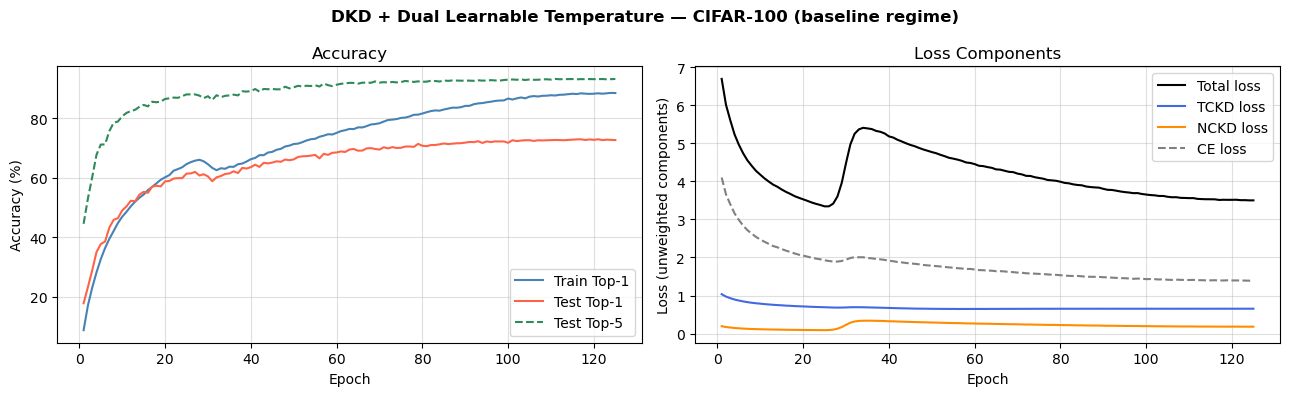

Curve data saved -> checkpoints/dkd_dual_temp_accuracy_loss_curves.json


In [41]:
ep = history['epoch']

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
fig.suptitle('DKD + Dual Learnable Temperature — CIFAR-100 (baseline regime)', fontweight='bold')

axes[0].plot(ep, history['train_acc'],  label='Train Top-1', color='steelblue')
axes[0].plot(ep, history['test_top1'],  label='Test Top-1',  color='tomato')
axes[0].plot(ep, history['test_top5'],  label='Test Top-5',  color='seagreen', linestyle='--')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Accuracy (%)')
axes[0].set_title('Accuracy'); axes[0].legend(); axes[0].grid(True, alpha=0.4)

axes[1].plot(ep, history['total_loss'], label='Total loss',  color='black')
axes[1].plot(ep, history['tckd_loss'],  label='TCKD loss',   color='royalblue')
axes[1].plot(ep, history['nckd_loss'],  label='NCKD loss',   color='darkorange')
axes[1].plot(ep, history['ce_loss'],    label='CE loss',     color='gray', linestyle='--')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Loss (unweighted components)')
axes[1].set_title('Loss Components'); axes[1].legend(); axes[1].grid(True, alpha=0.4)

plt.tight_layout(); plt.show()

with open(CKPT_DIR / 'dkd_dual_temp_accuracy_loss_curves.json', 'w') as f:
    json.dump({'epoch': history['epoch'], 'train_acc': history['train_acc'],
               'test_top1': history['test_top1'], 'test_top5': history['test_top5'],
               'total_loss': history['total_loss'], 'tckd_loss': history['tckd_loss'],
               'nckd_loss': history['nckd_loss'], 'ce_loss': history['ce_loss']}, f, indent=2)
print(f'Curve data saved -> {CKPT_DIR / "dkd_dual_temp_accuracy_loss_curves.json"}')


### 12.2 Temperature Curriculum

The central diagnostic: do $\tau_{TCKD}$ and $\tau_{NCKD}$ evolve differently?

- If they **diverge**: the two DKD components require different temperature scales, validating the dual-temperature design.
- If $\tau_{TCKD}$ rises and $\tau_{NCKD}$ falls (or vice versa): the GRL is finding asymmetric optima.
- If they stay flat: consider increasing `LR_TEMP` or `GRL_LAMBDA_MAX`.


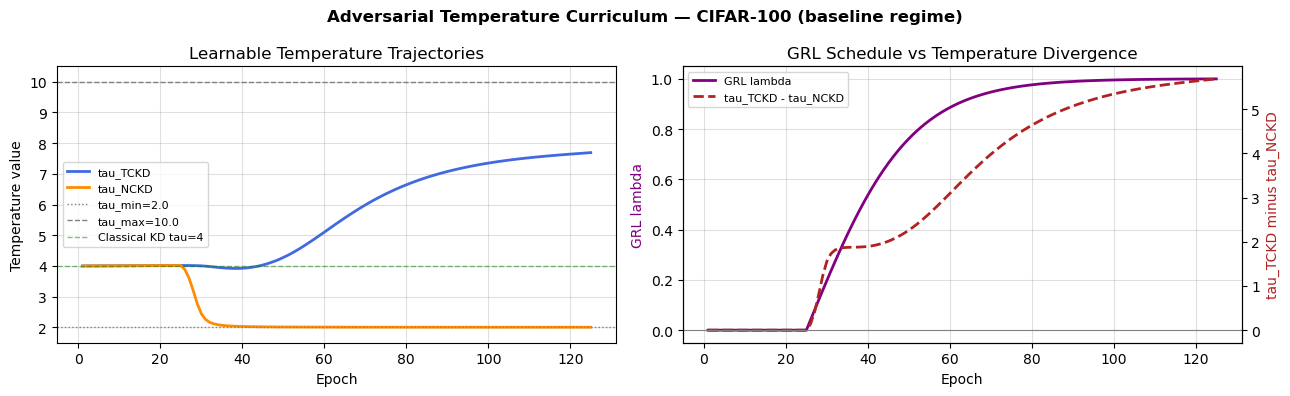

Temperature curriculum interpretation:
  Initial tau_TCKD : ~4.00  ->  Final: 7.690
  Initial tau_NCKD : ~4.00  ->  Final: 2.004
  Final divergence (TCKD - NCKD) : +5.685
Temperature data saved -> checkpoints/dkd_dual_temp_temperature_curriculum.json


In [42]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
fig.suptitle('Adversarial Temperature Curriculum — CIFAR-100 (baseline regime)', fontweight='bold')

axes[0].plot(ep, history['tau_tckd'], label='tau_TCKD', color='royalblue', linewidth=2)
axes[0].plot(ep, history['tau_nckd'], label='tau_NCKD', color='darkorange', linewidth=2)
axes[0].axhline(TAU_MIN, color='gray', linestyle=':', linewidth=1, label=f'tau_min={TAU_MIN}')
axes[0].axhline(TAU_MAX, color='gray', linestyle='--', linewidth=1, label=f'tau_max={TAU_MAX}')
axes[0].axhline(4.0, color='green', linestyle='--', linewidth=1, alpha=0.5, label='Classical KD tau=4')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Temperature value')
axes[0].set_title('Learnable Temperature Trajectories')
axes[0].set_ylim(TAU_MIN - 0.5, TAU_MAX + 0.5)
axes[0].legend(fontsize=8); axes[0].grid(True, alpha=0.4)

ax2  = axes[1]
ax2b = ax2.twinx()
tau_diff = [t - n for t, n in zip(history['tau_tckd'], history['tau_nckd'])]
ax2.plot(ep,  history['grl_lambda'], color='purple',   linewidth=2, label='GRL lambda')
ax2b.plot(ep, tau_diff,              color='firebrick', linewidth=2, linestyle='--', label='tau_TCKD - tau_NCKD')
ax2b.axhline(0, color='gray', linewidth=0.8)
ax2.set_xlabel('Epoch')
ax2.set_ylabel('GRL lambda', color='purple')
ax2b.set_ylabel('tau_TCKD minus tau_NCKD', color='firebrick')
ax2.set_title('GRL Schedule vs Temperature Divergence')
lines1, labels1 = ax2.get_legend_handles_labels()
lines2, labels2 = ax2b.get_legend_handles_labels()
ax2.legend(lines1 + lines2, labels1 + labels2, fontsize=8)
ax2.grid(True, alpha=0.4)

plt.tight_layout(); plt.show()

print('Temperature curriculum interpretation:')
print(f'  Initial tau_TCKD : ~4.00  ->  Final: {history["tau_tckd"][-1]:.3f}')
print(f'  Initial tau_NCKD : ~4.00  ->  Final: {history["tau_nckd"][-1]:.3f}')
print(f'  Final divergence (TCKD - NCKD) : {history["tau_tckd"][-1] - history["tau_nckd"][-1]:+.3f}')

with open(CKPT_DIR / 'dkd_dual_temp_temperature_curriculum.json', 'w') as f:
    json.dump({'epoch': history['epoch'], 'tau_tckd': history['tau_tckd'],
               'tau_nckd': history['tau_nckd'], 'tau_diff': tau_diff,
               'grl_lambda': history['grl_lambda'],
               'tau_min': float(TAU_MIN), 'tau_max': float(TAU_MAX)}, f, indent=2)
print(f'Temperature data saved -> {CKPT_DIR / "dkd_dual_temp_temperature_curriculum.json"}')


## 13. Results Summary

In [43]:
baseline_results = {
    'B1 ResNet-18 Teacher'          : {'top1': None, 'note': 'Teacher ceiling'},
    'B2 MobileNetV2 Vanilla'        : {'top1': None, 'note': 'Student w/o KD (retrained)'},
    'B3 MobileNetV2 + Classical KD' : {'top1': None, 'note': 'Primary baseline (retrained)'},
    'B4 DKD (cosine)'               : {'top1': None, 'note': 'DKD fixed tau, cosine regime'},
    'B5 CTKD (cosine)'              : {'top1': None, 'note': 'CTKD learnable tau, cosine regime'},
}

for ckpt_file, key in [
    ('b1_resnet18_teacher_cifar100.pth',            'B1 ResNet-18 Teacher'),
    ('b2_mobilenetv2_vanilla_cifar100.pth',         'B2 MobileNetV2 Vanilla'),
    ('b3_mobilenetv2_kd_cifar100.pth',              'B3 MobileNetV2 + Classical KD'),
    ('b4_mobilenetv2_dkd_cifar100_cosine.pth',      'B4 DKD (cosine)'),
    ('b5_mobilenetv2_ctkd_cifar100_cosine.pth',     'B5 CTKD (cosine)'),
]:
    path = CKPT_DIR / ckpt_file
    if path.exists():
        ckpt = torch.load(path, map_location='cpu')
        t1 = ckpt.get('top1', ckpt.get('val_top1', None))
        if t1:
            baseline_results[key]['top1'] = round(t1, 2)

rows = [{'Model': k, 'Top-1 (%)': v['top1'], 'Note': v['note']}
        for k, v in baseline_results.items()]
rows.append({
    'Model'     : 'B6 DKD + Dual Temp, cosine (ours)',
    'Top-1 (%)' : round(best_top1, 2),
    'Note'      : (f'Best epoch {best_epoch}  |  '
                   f'tau_TCKD={history["tau_tckd"][best_epoch-1]:.2f}  '
                   f'tau_NCKD={history["tau_nckd"][best_epoch-1]:.2f}  '
                   f'label_smooth=0.1'),
})

df = pd.DataFrame(rows)
print('=' * 80)
print('CIFAR-100 RESULTS — DKD + DUAL LEARNABLE TEMPERATURES (COSINE REGIME)')
print('=' * 80)
print(df.to_string(index=False))
print('=' * 80)

b3_top1 = baseline_results['B3 MobileNetV2 + Classical KD']['top1']
if b3_top1 is not None:
    print(f'\nGain vs classical KD (B6 - B3): {best_top1 - b3_top1:+.2f}%')

with open(CKPT_DIR / 'dkd_dual_temp_results_summary.json', 'w') as f:
    json.dump({'baseline_results': baseline_results,
               'best': {'top1': round(best_top1, 2),
                        'top5': round(history['test_top5'][best_epoch-1], 2),
                        'epoch': best_epoch,
                        'tau_tckd': history['tau_tckd'][best_epoch-1],
                        'tau_nckd': history['tau_nckd'][best_epoch-1]}}, f, indent=2)
print(f'Results saved -> {CKPT_DIR / "dkd_dual_temp_results_summary.json"}')


CIFAR-100 RESULTS — DKD + DUAL LEARNABLE TEMPERATURES (COSINE REGIME)
                            Model  Top-1 (%)                                                              Note
             B1 ResNet-18 Teacher        NaN                                                   Teacher ceiling
           B2 MobileNetV2 Vanilla      66.75                                        Student w/o KD (retrained)
    B3 MobileNetV2 + Classical KD      72.80                                      Primary baseline (retrained)
                  B4 DKD (cosine)      72.29                                      DKD fixed tau, cosine regime
                 B5 CTKD (cosine)      72.73                                 CTKD learnable tau, cosine regime
B6 DKD + Dual Temp, cosine (ours)      72.85 Best epoch 121  |  tau_TCKD=7.65  tau_NCKD=2.00  label_smooth=0.1

Gain vs classical KD (B6 - B3): +0.05%
Results saved -> checkpoints/dkd_dual_temp_results_summary.json


## 14. Full Training History Table

In [44]:
df_hist = pd.DataFrame({
    'Epoch'      : history['epoch'],
    'Total Loss' : [f'{v:.4f}' for v in history['total_loss']],
    'TCKD Loss'  : [f'{v:.4f}' for v in history['tckd_loss']],
    'NCKD Loss'  : [f'{v:.4f}' for v in history['nckd_loss']],
    'CE Loss'    : [f'{v:.4f}' for v in history['ce_loss']],
    'Train Acc'  : [f'{v:.2f}%' for v in history['train_acc']],
    'Test Top-1' : [f'{v:.2f}%' for v in history['test_top1']],
    'Test Top-5' : [f'{v:.2f}%' for v in history['test_top5']],
    'tau_TCKD'   : [f'{v:.3f}' for v in history['tau_tckd']],
    'tau_NCKD'   : [f'{v:.3f}' for v in history['tau_nckd']],
    'GRL lambda' : [f'{v:.3f}' for v in history['grl_lambda']],
})
print(df_hist.to_string(index=False))

with open(CKPT_DIR / 'dkd_dual_temp_epoch_history.json', 'w') as f:
    json.dump(history, f, indent=2)
print(f'\nEpoch-by-epoch history saved -> {CKPT_DIR / "dkd_dual_temp_epoch_history.json"}')


 Epoch Total Loss TCKD Loss NCKD Loss CE Loss Train Acc Test Top-1 Test Top-5 tau_TCKD tau_NCKD GRL lambda
     1     6.6892    1.0355    0.1943  4.0990     8.70%     17.73%     44.45%    4.001    4.001      0.000
     2     6.0112    0.9717    0.1727  3.6578    16.96%     23.18%     52.93%    4.001    4.001      0.000
     3     5.6059    0.9308    0.1596  3.3985    22.96%     28.79%     60.11%    4.002    4.002      0.000
     4     5.2319    0.8949    0.1475  3.1573    28.08%     34.92%     67.62%    4.003    4.003      0.000
     5     4.9613    0.8681    0.1384  2.9861    32.56%     37.63%     71.08%    4.003    4.003      0.000
     6     4.7372    0.8461    0.1317  2.8377    36.28%     38.48%     71.13%    4.004    4.004      0.000
     7     4.5500    0.8259    0.1259  2.7168    39.39%     43.16%     75.60%    4.004    4.004      0.000
     8     4.4076    0.8101    0.1215  2.6252    42.01%     45.78%     78.41%    4.005    4.005      0.000
     9     4.2742    0.7970    0.1172